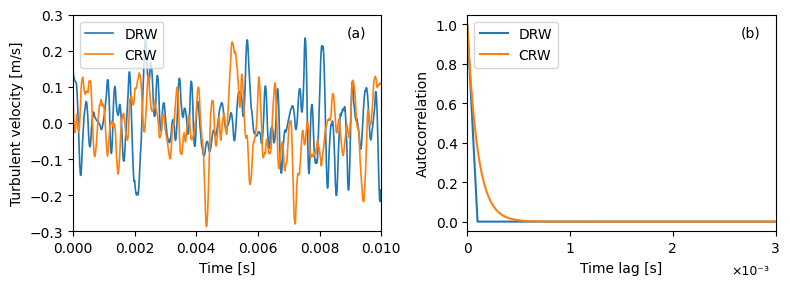

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ==========================
# Parameters from paper
# ==========================

u0 = 0.1
sigma = 0.1
dt = 1e-5
tau = 1e-4

T = 1e-2
N = int(T/dt)

t = np.arange(N) * dt

np.random.seed(10)

# ==================================================
# DRW
# ==================================================

u_drw = np.zeros(N)

eddy_steps = int(tau/dt)

current_velocity = u0

for i in range(N):

    if i % eddy_steps == 0:
        current_velocity = sigma * np.random.randn()

    u_drw[i] = current_velocity

# ==================================================
# CRW
# ==================================================

u_crw = np.zeros(N)

u_crw[0] = u0

A = np.exp(-dt/tau)
B = sigma * np.sqrt(1 - np.exp(-2*dt/tau))

for i in range(N-1):

    xi = np.random.randn()

    u_crw[i+1] = A*u_crw[i] + B*xi

# ==================================================
# Smoothing
# ==================================================

u_drw_s = savgol_filter(u_drw, 21, 3)
u_crw_s = savgol_filter(u_crw, 21, 3)

# ==================================================
# Theoretical ACF
# ==================================================

maxlag = int(3e-3/dt)

lag = np.arange(maxlag) * dt

acf_crw = np.exp(-lag/tau)

acf_drw = np.where(
    lag < tau,
    1 - lag/tau,
    0
)

# ==================================================
# Plot
# ==================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,3)
)

# -------------------------
# Figure 1a
# -------------------------

ax[0].plot(
    t,
    u_drw_s,
    lw=1.2,
    label='DRW'
)

ax[0].plot(
    t,
    u_crw_s,
    lw=1.2,
    label='CRW'
)

ax[0].set_xlim(0,0.01)
ax[0].set_ylim(-0.3,0.3)

ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Turbulent velocity [m/s]')

ax[0].legend()

ax[0].text(
    0.95,
    0.95,
    '(a)',
    transform=ax[0].transAxes,
    ha='right',
    va='top'
)

# -------------------------
# Figure 1b
# -------------------------

ax[1].plot(
    lag,
    acf_drw,
    lw=1.5,
    label='DRW'
)

ax[1].plot(
    lag,
    acf_crw,
    lw=1.5,
    label='CRW'
)

ax[1].set_xlim(0, 3e-3)
ax[1].set_ylim(-0.05, 1.05)

# Add these 4 lines to fix the x-axis
from matplotlib.ticker import FuncFormatter, MultipleLocator
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*1000:.0f}'))
ax[1].xaxis.set_major_locator(MultipleLocator(1e-3))
ax[1].text(0.98, -0.15, '×10⁻³', transform=ax[1].transAxes, ha='right', va='top', fontsize=9)

# ============ REST OF YOUR CODE (UNCHANGED) ============

ax[1].set_xlabel('Time lag [s]')
ax[1].set_ylabel('Autocorrelation')
ax[1].legend()
ax[1].text(
    0.95,
    0.95,
    '(b)',
    transform=ax[1].transAxes,
    ha='right',
    va='top'
)

plt.tight_layout()
plt.show()

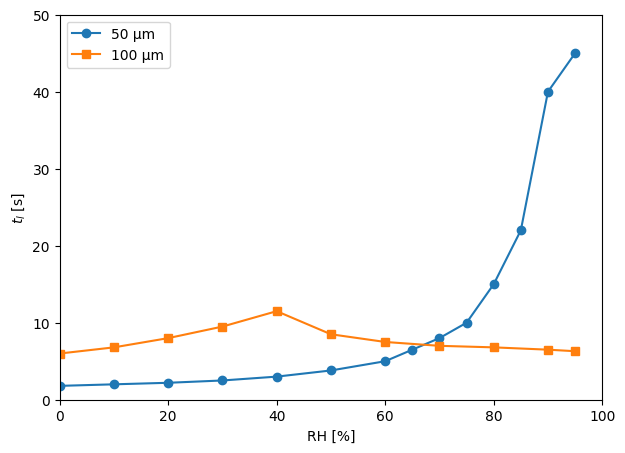

In [1]:
import numpy as np
import matplotlib.pyplot as plt


RH_50 = np.array([
0,10,20,30,40,50,60,65,70,75,80,85,90,95
])

tl_50 = np.array([
1.8,2.0,2.2,2.5,3.0,3.8,5.0,
6.5,8.0,10.0,15,22,40,45
])


RH_100 = np.array([
0,10,20,30,40,50,60,70,80,90,95
])

tl_100 = np.array([
6,6.8,8,9.5,11.5,8.5,
7.5,7,6.8,6.5,6.3
])


plt.figure(figsize=(7,5))

plt.plot(
    RH_50,
    tl_50,
    'o-',
    label='50 μm'
)

plt.plot(
    RH_100,
    tl_100,
    's-',
    label='100 μm'
)


plt.xlabel("RH [%]")
plt.ylabel("$t_l$ [s]")

plt.legend()
plt.grid(False)

plt.xlim(0,100)
plt.ylim(0,50)

plt.show()

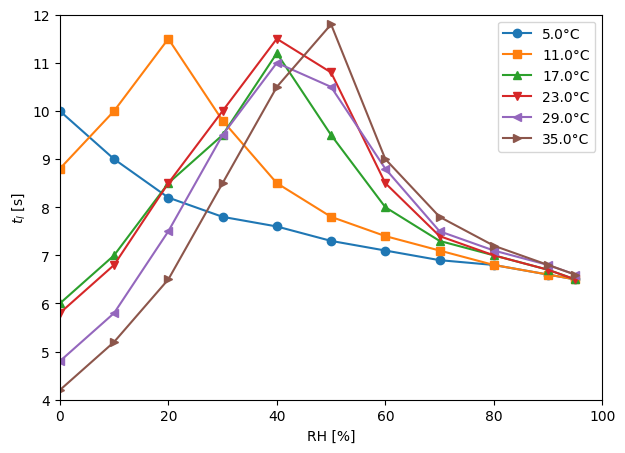

In [3]:
import numpy as np
import matplotlib.pyplot as plt


RH = np.array([
    0,10,20,30,40,50,60,70,80,90,95
])


# Temperature = 5 C
t_5 = np.array([
    10,9,8.2,7.8,7.6,7.3,7.1,6.9,6.8,6.6,6.5
])


# Temperature = 11 C
t_11 = np.array([
    8.8,10,11.5,9.8,8.5,7.8,7.4,7.1,6.8,6.6,6.5
])


# Temperature = 17 C
t_17 = np.array([
    6,7,8.5,9.5,11.2,9.5,8.0,7.3,7.0,6.7,6.5
])


# Temperature = 23 C
t_23 = np.array([
    5.8,6.8,8.5,10,11.5,10.8,8.5,7.4,7.0,6.7,6.5
])


# Temperature = 29 C
t_29 = np.array([
    4.8,5.8,7.5,9.5,11.0,10.5,8.8,7.5,7.1,6.8,6.6
])


# Temperature = 35 C
t_35 = np.array([
    4.2,5.2,6.5,8.5,10.5,11.8,9.0,7.8,7.2,6.8,6.6
])


plt.figure(figsize=(7,5))


plt.plot(RH,t_5,'o-',label="5.0°C")
plt.plot(RH,t_11,'s-',label="11.0°C")
plt.plot(RH,t_17,'^-',label="17.0°C")
plt.plot(RH,t_23,'v-',label="23.0°C")
plt.plot(RH,t_29,'<-',label="29.0°C")
plt.plot(RH,t_35,'>-',label="35.0°C")


plt.xlabel("RH [%]")
plt.ylabel("$t_l$ [s]")


plt.xlim(0,100)
plt.ylim(4,12)

plt.legend()
plt.grid(False)

plt.show()

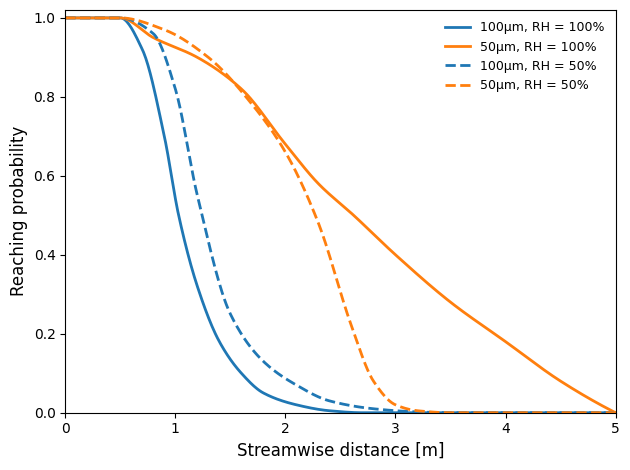

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# ---------- 100 μm RH=100 ----------
x1 = np.array([0,0.5,0.7,0.9,1.03,1.2,1.4,1.6,1.8,2.1,2.4,2.7])
y1 = np.array([1,1,0.92,0.70,0.50,0.32,0.18,0.10,0.05,0.02,0.005,0])

# ---------- 100 μm RH=50 ----------
x2 = np.array([0,0.5,0.8,1.0,1.2,1.5,1.8,2.1,2.4,2.8,3.2,3.5])
y2 = np.array([1,1,0.96,0.82,0.55,0.25,0.13,0.07,0.03,0.01,0.002,0])

# ---------- 50 μm RH=100 ----------
x3 = np.array([0,0.5,0.8,1.2,1.6,2.0,2.3,2.62,3.0,3.5,4.0,4.5,5.0])
y3 = np.array([1,1,0.95,0.90,0.82,0.68,0.58,0.50,0.40,0.28,0.18,0.08,0])

# ---------- 50 μm RH=50 ----------
x4 = np.array([0,0.5,0.9,1.3,1.7,2.0,2.3,2.6,2.8,3.0,3.2,3.5])
y4 = np.array([1,1,0.97,0.90,0.78,0.66,0.48,0.22,0.08,0.02,0.005,0])

f1=PchipInterpolator(x1,y1)
f2=PchipInterpolator(x2,y2)
f3=PchipInterpolator(x3,y3)
f4=PchipInterpolator(x4,y4)

xx=np.linspace(0,5,500)

plt.figure(figsize=(6.4,4.8))

plt.plot(xx,f1(np.clip(xx,x1.min(),x1.max())),
         color='tab:blue',lw=2,label='100μm, RH = 100%')

plt.plot(xx,f3(np.clip(xx,x3.min(),x3.max())),
         color='tab:orange',lw=2,label='50μm, RH = 100%')

plt.plot(xx,f2(np.clip(xx,x2.min(),x2.max())),
         '--',color='tab:blue',lw=2,label='100μm, RH = 50%')

plt.plot(xx,f4(np.clip(xx,x4.min(),x4.max())),
         '--',color='tab:orange',lw=2,label='50μm, RH = 50%')

plt.xlim(0,5)
plt.ylim(0,1.02)

plt.xlabel("Streamwise distance [m]",fontsize=12)
plt.ylabel("Reaching probability",fontsize=12)

plt.xticks(np.arange(0,6,1))
plt.yticks(np.arange(0,1.1,0.2))

plt.legend(frameon=False,fontsize=9)
plt.tight_layout()
plt.show()

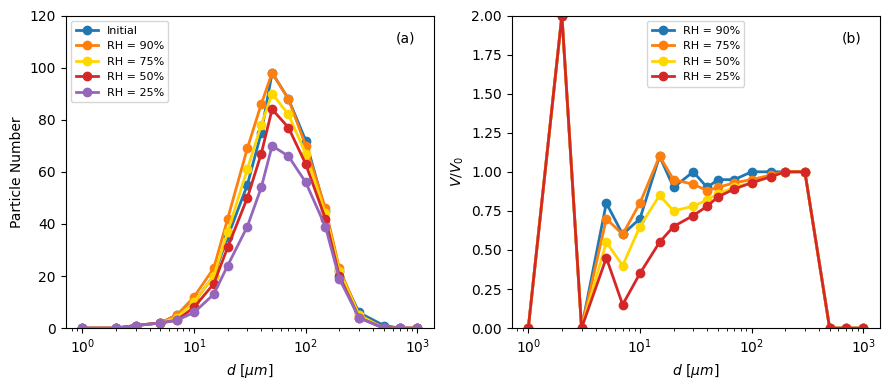

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# قطر (µm)
# -----------------------------
d = np.array([1,2,3,5,7,10,15,20,30,40,50,70,100,150,200,300,500,700,1000])

# شکل (a): Particle Number
d = np.array([
1,2,3,5,7,10,15,20,30,40,50,70,100,150,200,300,500,700,1000
])

Initial = np.array([
0,0,1,2,5,12,25,45,72,88,100,90,72,48,24,6,0,0,0
])

RH90 = np.array([
0,0,1,2,5,12,23,42,69,86,98,88,70,46,23,5,0,0,0
])

RH75 = np.array([
0,0,1,2,4,10,20,37,61,78,90,82,67,44,22,5,0,0,0
])

RH50 = np.array([
0,0,1,2,3,8,17,31,50,67,84,77,63,42,20,4,0,0,0
])

RH25 = np.array([
0,0,1,2,3,6,13,24,39,54,70,66,56,39,19,4,0,0,0
])

# -----------------------------
# شکل (b): V/V0
# -----------------------------
V90 = np.array([
0,2.0,0.0,0.70,0.60,0.80,1.10,0.95,
0.92,0.88,0.90,0.93,0.95,0.98,1.0,1.0,0,0,0
])

V75 = np.array([
0,2.0,0.0,0.55,0.40,0.65,0.85,0.75,
0.78,0.82,0.86,0.90,0.93,0.97,1.0,1.0,0,0,0
])

V50 = np.array([
0,2.0,0.0,0.45,0.15,0.35,0.55,0.65,
0.72,0.78,0.84,0.89,0.93,0.97,1.0,1.0,0,0,0
])

V25 = np.array([
0,2.0,0.0,0.05,0.00,0.10,0.25,0.45,
0.62,0.72,0.80,0.87,0.91,0.96,1.0,1.0,0,0,0
])

# -----------------------------
# رسم
# -----------------------------
fig,ax=plt.subplots(1,2,figsize=(9,4))

colors=['tab:blue','tab:orange','gold','tab:red','tab:purple']
labels=['Initial','RH = 90%','RH = 75%','RH = 50%','RH = 25%']

# (a)
ax[0].set_xscale('log')
ax[0].plot(d,RH100,'o-',lw=2,color=colors[0],label=labels[0])
ax[0].plot(d,RH90,'o-',lw=2,color=colors[1],label=labels[1])
ax[0].plot(d,RH75,'o-',lw=2,color=colors[2],label=labels[2])
ax[0].plot(d,RH50,'o-',lw=2,color=colors[3],label=labels[3])
ax[0].plot(d,RH25,'o-',lw=2,color=colors[4],label=labels[4])

ax[0].set_ylim(0,120)
ax[0].set_xlabel(r'$d\ [\mu m]$')
ax[0].set_ylabel('Particle Number')
ax[0].legend(fontsize=8)
ax[0].text(0.95,0.95,'(a)',ha='right',va='top',transform=ax[0].transAxes)

# (b)
ax[1].set_xscale('log')
ax[1].plot(d,V100,'o-',lw=2,color=colors[0],label='RH = 90%')
ax[1].plot(d,V90,'o-',lw=2,color=colors[1],label='RH = 75%')
ax[1].plot(d,V75,'o-',lw=2,color=colors[2],label='RH = 50%')
ax[1].plot(d,V50,'o-',lw=2,color=colors[3],label='RH = 25%')

ax[1].set_ylim(0,2)
ax[1].set_xlabel(r'$d\ [\mu m]$')
ax[1].set_ylabel(r'$V/V_0$')
ax[1].legend(fontsize=8)
ax[1].text(0.95,0.95,'(b)',ha='right',va='top',transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

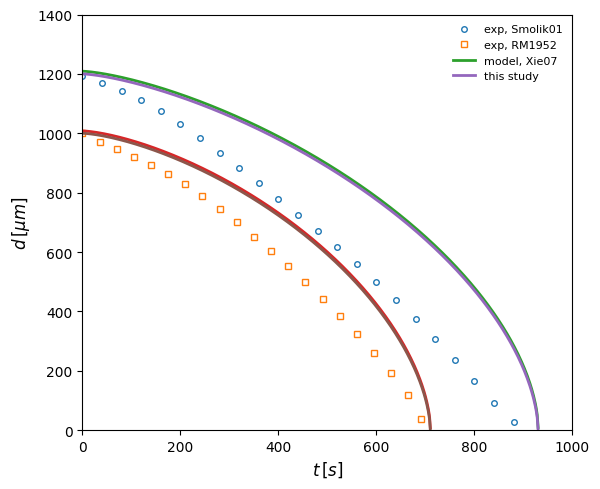

In [15]:
import numpy as np
import matplotlib.pyplot as plt

t_blue=np.linspace(0,930,500)
t_red=np.linspace(0,710,500)

d_blue_this=1200*np.power(np.maximum(1-(t_blue/930)**1.43,0),0.57)
d_red_this=1000*np.power(np.maximum(1-(t_red/710)**1.48,0),0.58)

d_blue_xie=d_blue_this+9
d_red_xie=d_red_this+8

ts=np.array([0,40,80,120,160,200,240,280,320,360,400,440,480,520,560,600,640,680,720,760,800,840,880])

ds=np.array([
1192,
1170,
1142,
1112,
1076,
1032,
984,
934,
884,
832,
780,
726,
672,
618,
560,
500,
438,
374,
308,
238,
166,
92,
28
])

tr=np.array([0,35,70,105,140,175,210,245,280,315,350,385,420,455,490,525,560,595,630,665,690])

dr=np.array([
1000,
972,
946,
920,
892,
862,
830,
790,
746,
700,
652,
604,
552,
498,
442,
384,
324,
260,
192,
118,
38
])

plt.figure(figsize=(6.1,5))

plt.plot(ts,ds,'o',mfc='none',ms=4,label='exp, Smolik01')
plt.plot(tr,dr,'s',mfc='none',ms=4,label='exp, RM1952')

plt.plot(t_blue,d_blue_xie,lw=2,label='model, Xie07')
plt.plot(t_red,d_red_xie,lw=2)

plt.plot(t_blue,d_blue_this,lw=2,label='this study')
plt.plot(t_red,d_red_this,lw=2)

plt.xlim(0,1000)
plt.ylim(0,1400)

plt.xticks(np.arange(0,1001,200))
plt.yticks(np.arange(0,1401,200))

plt.xlabel(r'$t\,[s]$',fontsize=12)
plt.ylabel(r'$d\,[\mu m]$',fontsize=12)

plt.legend(frameon=False,fontsize=8,loc='upper right')

plt.tight_layout()
plt.show()

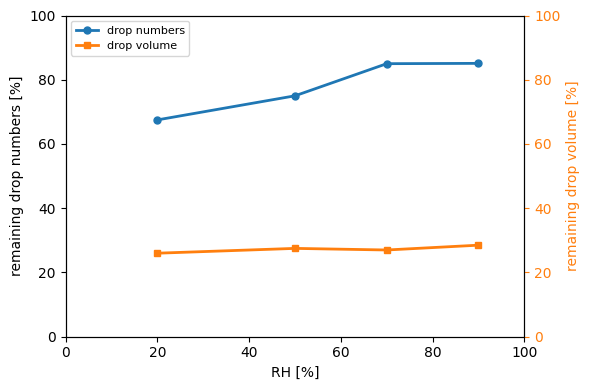

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# RH (%)
RH = np.array([20, 50, 70, 90])

# Remaining drop numbers (%)
drop_numbers = np.array([
    67.5,
    75.0,
    85.0,
    85.1
])

# Remaining drop volume (%)
drop_volume = np.array([
    26.0,
    27.5,
    27.0,
    28.5
])

fig, ax1 = plt.subplots(figsize=(6,4))

# Left axis
ax1.plot(
    RH,
    drop_numbers,
    'o-',
    color='tab:blue',
    linewidth=2,
    markersize=5,
    label='drop numbers'
)

ax1.set_xlim(0,100)
ax1.set_ylim(0,100)
ax1.set_xlabel("RH [%]")
ax1.set_ylabel("remaining drop numbers [%]")

# Right axis
ax2 = ax1.twinx()

ax2.plot(
    RH,
    drop_volume,
    's-',
    color='tab:orange',
    linewidth=2,
    markersize=5,
    label='drop volume'
)

ax2.set_ylim(0,100)
ax2.set_ylabel("remaining drop volume [%]", color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np

#----------Function f1------------
def f1(x, y1, y2):
    ans1 = y2 + (x**2)
    return ans1


#----------Function f1------------
def f2(x, y1, y2):
    ans2 = y1 - x
    return ans2


#-------------main----------------
y_1 = [4]
y_2 = [6]

a = 0
b = 1
h = 0.0001

bazeh = np.arange(a, b, h)

i = 0
for x in bazeh:
    y1 = y_1[i]
    y2 = y_2[i]

    k11 = f1(x, y1, y2)
    k12 = f2(x, y1, y2)

    k21 = f1(x+0.5*h, y1+0.5*h*k11, y2+0.5*h*k12)
    k22 = f2(x+0.5*h, y1+0.5*h*k11, y2+0.5*h*k12)

    k31 = f1(x+0.5*h, y1+0.5*h*k21, y2+0.5*h*k22)
    k32 = f2(x+0.5*h, y1+0.5*h*k21, y2+0.5*h*k22)

    k41 = f1(x+0.5*h, y1+0.5*h*k31, y2+0.5*h*k32)
    k42 = f2(x+0.5*h, y1+0.5*h*k31, y2+0.5*h*k32)

    y1 = y_1[i]+(k11+2*k21+2*k31+k41)*h/6
    y2 = y_2[i]+(k21+2*k22+2*k32+k42)*h/6

    y_1.append(y1)
    y_2.append(y2)
    i = i+1


print(y_1[5000])
print(y_2[5000])



7.699366340218131
8.895398169385343
